In [4]:
import kagglehub
import os
import random
from PIL import Image


In [3]:
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = os.path.join("..", path, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)")
train_path = path+"/train"
val_path = path+"/valid"



Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


Cherry_(including_sour)___Powdery_mildew
256
256


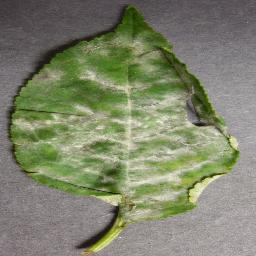

In [5]:

classes = [name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, name))]
class_name = random.choice(classes)
class_path = os.path.join(train_path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path)

print(class_name)
print(img.width)
print(img.height)
img

In [6]:
import torch

In [7]:
s=torch.tensor(10)
s

tensor(10)

In [8]:
v=torch.tensor([6,6])

v
v.ndim


1

In [9]:
b=torch.tensor([[6,6],
                [9,5],
                [23,54]])
b
b.ndim

2

In [10]:
v=v.unsqueeze(dim=0)
v=v.unsqueeze(dim=1)
v

tensor([[[6, 6]]])

In [11]:
v=v.squeeze(dim=0)
v


tensor([[6, 6]])

In [12]:
r=torch.arange(1,10)
r
torch.reshape(r,(3,3))

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [13]:
torch.arange(9).reshape(3, 3)

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

In [14]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [15]:
weights, bias = 0.6, 0.03
x = torch.arange(0, 1, 0.02).unsqueeze(dim=1).float()
y = weights * x + bias
len(x),len(y)

(50, 50)

In [16]:
train_split = int(0.8 * len(x))
x_train, y_train = x[:train_split], y[:train_split]
x_test, y_test = x[train_split:], y[train_split:]


In [17]:
class simplereggModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x):
        return (self.weight * x) + self.bias

In [18]:

torch.manual_seed(42)
model_first = simplereggModel()
model_first.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [19]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_first.parameters(), lr=0.00001)

In [20]:
def plot_predictions(x_train, y_train, x_test, y_test, y_preds=None):
    plt.scatter(x_train, y_train, c="b", label="Train")
    plt.scatter(x_test, y_test, c="g", label="Test")
    if y_preds is not None:
        plt.scatter(x_test, y_preds, c="r", label="Preds")
    plt.legend()
    plt.show()

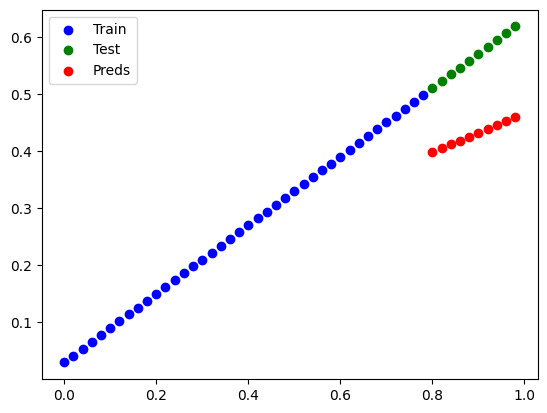

In [21]:
with torch.inference_mode():
    y_preds = model_first(x_test)

plot_predictions(x_train, y_train, x_test, y_test, y_preds)

In [22]:
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs):
  model_first.train()

  y_pred = model_first(x_train)

  loss = loss_fn(y_pred, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_first.eval()
  with torch.inference_mode():
    test_pred = model_first(x_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    print(f"epoch {epoch} | loss {loss} | test loss {test_loss}")

epoch 0 | loss 0.05272434279322624 | test loss 0.13553373515605927
epoch 10 | loss 0.05271931737661362 | test loss 0.13550928235054016
epoch 20 | loss 0.052714306861162186 | test loss 0.13548487424850464
epoch 30 | loss 0.052709292620420456 | test loss 0.13546042144298553
epoch 40 | loss 0.05270427465438843 | test loss 0.13543601334095
epoch 50 | loss 0.0526992492377758 | test loss 0.1354115754365921
epoch 60 | loss 0.052694231271743774 | test loss 0.1353871375322342
epoch 70 | loss 0.052689217031002045 | test loss 0.13536271452903748
epoch 80 | loss 0.052684199064970016 | test loss 0.13533827662467957
epoch 90 | loss 0.05267918109893799 | test loss 0.13531386852264404


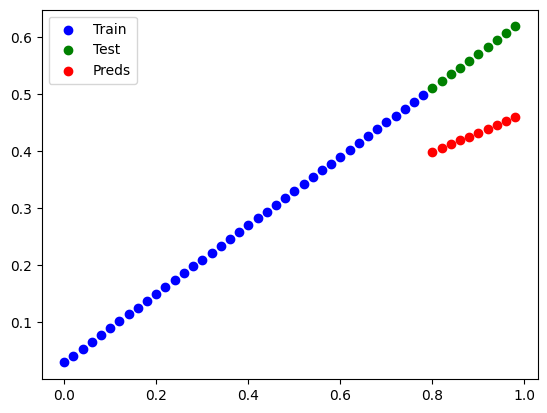

In [23]:
with torch.inference_mode():
  y_preds = model_first(x_test)
plot_predictions(x_train, y_train, x_test, y_test, y_preds)

In [24]:
len(classes)

38

In [25]:
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms


In [26]:
# img,label=valid_dataset[0]
# img.shape

In [27]:
data_transformer = transforms.Compose([
    transforms.Resize((106,106)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.654,0.987,0.969],std=[0.25,0.654,0.98])
])

train_dataset = datasets.ImageFolder(root = train_path, transform=None)

valid_dataset = datasets.ImageFolder(root = val_path, transform=data_transformer)
len(train_dataset), len(valid_dataset)

(70295, 17572)

In [28]:
transformed_img = data_transformer(img)
print(transformed_img)

tensor([[[-1.6278, -1.6435, -1.6121,  ..., -1.2042, -1.0944, -1.1101],
         [-1.5650, -1.5807, -1.5650,  ..., -1.1258, -1.0944, -1.1885],
         [-1.5807, -1.5964, -1.5964,  ..., -1.1258, -1.0944, -1.1258],
         ...,
         [-0.4827, -0.5140, -0.5768,  ...,  0.0193,  0.1291,  0.1134],
         [-0.5611, -0.4513, -0.4984,  ...,  0.0193,  0.0036,  0.0036],
         [-0.5925, -0.5454, -0.5297,  ..., -0.0748, -0.0591,  0.0507]],

        [[-1.1674, -1.1734, -1.1614,  ..., -1.0055, -0.9635, -0.9695],
         [-1.1434, -1.1494, -1.1434,  ..., -0.9755, -0.9635, -0.9995],
         [-1.1494, -1.1554, -1.1554,  ..., -0.9755, -0.9635, -0.9755],
         ...,
         [-0.7596, -0.7716, -0.7956,  ..., -0.5378, -0.4958, -0.5018],
         [-0.7896, -0.7476, -0.7656,  ..., -0.5378, -0.5438, -0.5438],
         [-0.8016, -0.7836, -0.7776,  ..., -0.5738, -0.5678, -0.5258]],

        [[-0.7527, -0.7567, -0.7487,  ..., -0.6366, -0.6086, -0.6126],
         [-0.7367, -0.7407, -0.7367,  ..., -0

In [29]:
train_loader=DataLoader(dataset=train_dataset,batch_size=32,shuffle=True)
valid_loader=DataLoader(dataset=valid_dataset,batch_size=32,shuffle=False)
print(f"Training images: {len(train_loader)}, Validation images: {len(valid_loader)}")

Training images: 2197, Validation images: 550


In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [31]:
dummy_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
train_dataset = datasets.ImageFolder(root = train_path, transform=dummy_transform)

In [32]:
mean = [0.2345, 0.50343, 0.0957]
std = [0.9384, 0.6323, 0.93863]
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
     transforms.RandomErasing(p=0.5, scale=(0.02,0.2))
])
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])
train_dataset = datasets.ImageFolder(root = train_path, transform=train_transform)
test_dataset = datasets.ImageFolder(root = train_path, transform=test_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle = False, num_workers=2)

In [33]:

class simpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,32, kernel_size=3, stride=1, padding=1),  #Layer 1
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32,64, kernel_size=3, stride=1, padding=1),  #Layer 2
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*56*56,128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x
model = simpleCNN(num_classes=10)
print(model)


simpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [34]:
# Step 1: Define Loss Function and Optimizer
model = simpleCNN(num_classes=len(classes)) # Create an instance of the model
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [35]:
# Steps 2 & 3: Implement Training and Evaluation Loops
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss

def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(test_loader.dataset)
    accuracy = 100 * correct / total
    return epoch_loss, accuracy

In [ ]:
# Step 4: Train the Model
num_epochs = 10
train_losses = []
test_losses = []
test_accuracies = []

model.to(device)

for epoch in range(num_epochs):
    train_loss = train_model(model, train_loader, criterion, optimizer, device)
    test_loss, test_accuracy = evaluate_model(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

Epoch 1/10, Train Loss: 0.2712, Test Loss: 0.1405, Test Accuracy: 95.39%


In [42]:
torch.save(model.state_dict(), "Image_Model.pth")

In [43]:
from google.colab import files
files.download("Image_Model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>